We wanted to find out if the stereotypes are true.

"YouTube" trouble sleeping
"Instagram" social comparison
"Facebook",
"Twitter" feeling depressed 
"TikTok" concentration
"Snapchat", "Discord","Pinterest","Reddit","LinkedIn"

In [3]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import numpy as np
from scipy.stats import gaussian_kde
import json, re

# data
data = pd.read_csv('../data/smmh.csv')

    Platform  Users  Average Age    Q9   Q10   Q11   Q12   Q13   Q14   Q15  \
0  Instagram    359        24.37  3.64  3.48  2.67  3.48  3.75  3.39  2.93   
1   Facebook    407        26.15  3.58  3.40  2.64  3.36  3.61  3.28  2.92   
2    Twitter    131        26.89  3.54  3.18  2.55  3.34  3.68  3.16  2.66   
3    YouTube    412        25.87  3.59  3.34  2.59  3.35  3.60  3.24  2.85   
4    Discord    198        22.81  3.67  3.43  2.55  3.48  3.75  3.40  2.79   
5  Pinterest    145        24.57  3.62  3.36  2.57  3.35  3.72  3.17  2.85   
6     TikTok     94        23.67  3.84  3.78  3.02  3.80  4.03  3.66  3.40   
7   Snapchat    181        22.76  3.72  3.60  2.78  3.61  3.84  3.51  3.04   
8     Reddit    126        23.56  3.68  3.20  2.38  3.43  3.73  3.30  2.60   

    Q16   Q17   Q18   Q19   Q20  
0  2.75  2.54  3.40  3.28  3.30  
1  2.74  2.53  3.31  3.17  3.25  
2  2.75  2.31  3.25  2.97  3.21  
3  2.78  2.46  3.28  3.18  3.22  
4  2.85  2.38  3.41  3.18  3.40  
5  2.79  2.50  

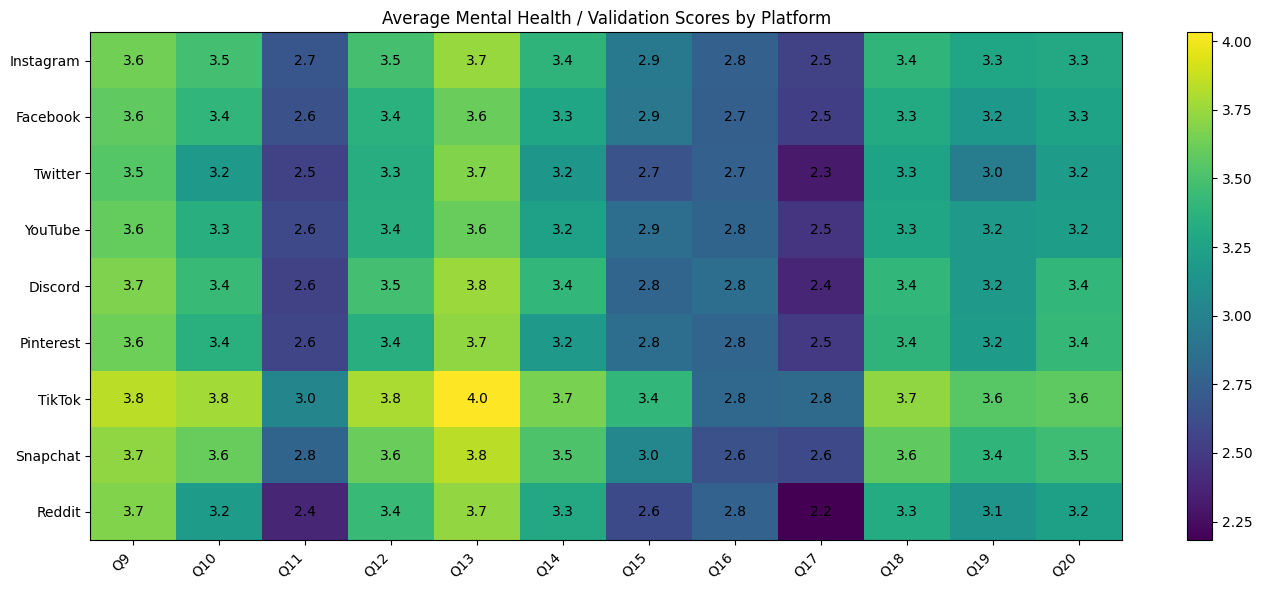

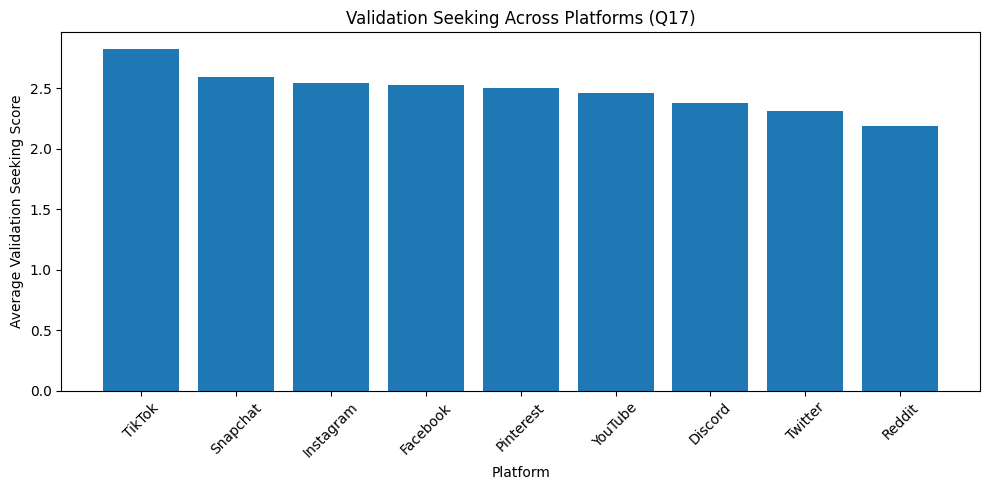


Instagram user occupation breakdown:
4. Occupation Status
University Student    67.1
Salaried Worker       20.6
School Student        11.1
Retired                1.1
Name: proportion, dtype: float64

--- QUICK SUMMARY ---
Average Instagram user age: 24.4
Average Instagram validation-seeking score: 2.54


In [4]:
# -----------------------------
# COLUMN DEFINITIONS
# -----------------------------
question_cols = {
    9: "9. How often do you find yourself using Social media without a specific purpose?",
    10: "10. How often do you get distracted by Social media when you are busy doing something?",
    11: "11. Do you feel restless if you haven't used Social media in a while?",
    12: "12. On a scale of 1 to 5, how easily distracted are you?",
    13: "13. On a scale of 1 to 5, how much are you bothered by worries?",
    14: "14. Do you find it difficult to concentrate on things?",
    15: "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?",
    16: "16. Following the previous question, how do you feel about these comparisons, generally speaking?",
    17: "17. How often do you look to seek validation from features of social media?",
    18: "18. How often do you feel depressed or down?",
    19: "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?",
    20: "20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
}

platform_col = "7. What social media platforms do you commonly use?"

# -----------------------------
# CREATE PLATFORM TABLE
# -----------------------------
platforms = [
    "Instagram",
    "Facebook",
    "Twitter",
    "YouTube",
    "Discord",
    "Pinterest",
    "TikTok",
    "Snapchat",
    "Reddit",
    "LinkedIn"
]

results = []

for platform in platforms:

    subset = data[
        data[platform_col]
        .fillna("")
        .str.contains(platform, case=False)
    ]

    if len(subset) == 0:
        continue

    row = {
        "Platform": platform,
        "Users": len(subset),
        "Average Age": subset["1. What is your age?"].mean(),
    }

    # Mean scores for Q9-Q20
    for q_num, q_col in question_cols.items():
        row[f"Q{q_num}"] = pd.to_numeric(
            subset[q_col],
            errors="coerce"
        ).mean()

    results.append(row)

platform_scores = pd.DataFrame(results)

# -----------------------------
# PRINT SUMMARY
# -----------------------------
print(platform_scores.round(2))

# -----------------------------
# HEATMAP VISUALIZATION
# -----------------------------
score_cols = [f"Q{i}" for i in range(9, 21)]

heatmap_data = platform_scores.set_index("Platform")[score_cols]

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(heatmap_data, aspect='auto')

# Axis labels
ax.set_xticks(np.arange(len(score_cols)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(score_cols)
ax.set_yticklabels(heatmap_data.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Add values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(score_cols)):
        value = heatmap_data.iloc[i, j]
        ax.text(j, i, f"{value:.1f}",
                ha="center",
                va="center")

ax.set_title("Average Mental Health / Validation Scores by Platform")

fig.colorbar(im)

plt.tight_layout()
plt.show()

# -----------------------------
# VALIDATION SEEKING PLOT
# -----------------------------
plt.figure(figsize=(10, 5))

validation_scores = platform_scores.sort_values("Q17", ascending=False)

plt.bar(
    validation_scores["Platform"],
    validation_scores["Q17"]
)

plt.ylabel("Average Validation Seeking Score")
plt.xlabel("Platform")
plt.title("Validation Seeking Across Platforms (Q17)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# -----------------------------
# OCCUPATION BREAKDOWN
# -----------------------------
occupation_col = "4. Occupation Status"

instagram_users = data[
    data[platform_col]
    .fillna("")
    .str.contains("Instagram", case=False)
]

print("\nInstagram user occupation breakdown:")
print(
    instagram_users[occupation_col]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

# -----------------------------
# QUICK SUMMARY TEXT
# -----------------------------
avg_age = instagram_users["1. What is your age?"].mean()

avg_validation = pd.to_numeric(
    instagram_users[question_cols[17]],
    errors="coerce"
).mean()

print("\n--- QUICK SUMMARY ---")
print(f"Average Instagram user age: {avg_age:.1f}")
print(f"Average Instagram validation-seeking score: {avg_validation:.2f}")

   Question Most Associated Platform(s)  Average Score
0        Q9                      TikTok           3.84
1       Q10                      TikTok           3.78
2       Q11                      TikTok           3.02
3       Q12                      TikTok           3.80
4       Q13                      TikTok           4.03
5       Q14                      TikTok           3.66
6       Q15                      TikTok           3.40
7       Q16                     Discord           2.85
8       Q17                      TikTok           2.82
9       Q18                      TikTok           3.72
10      Q19                      TikTok           3.55
11      Q20                      TikTok           3.57


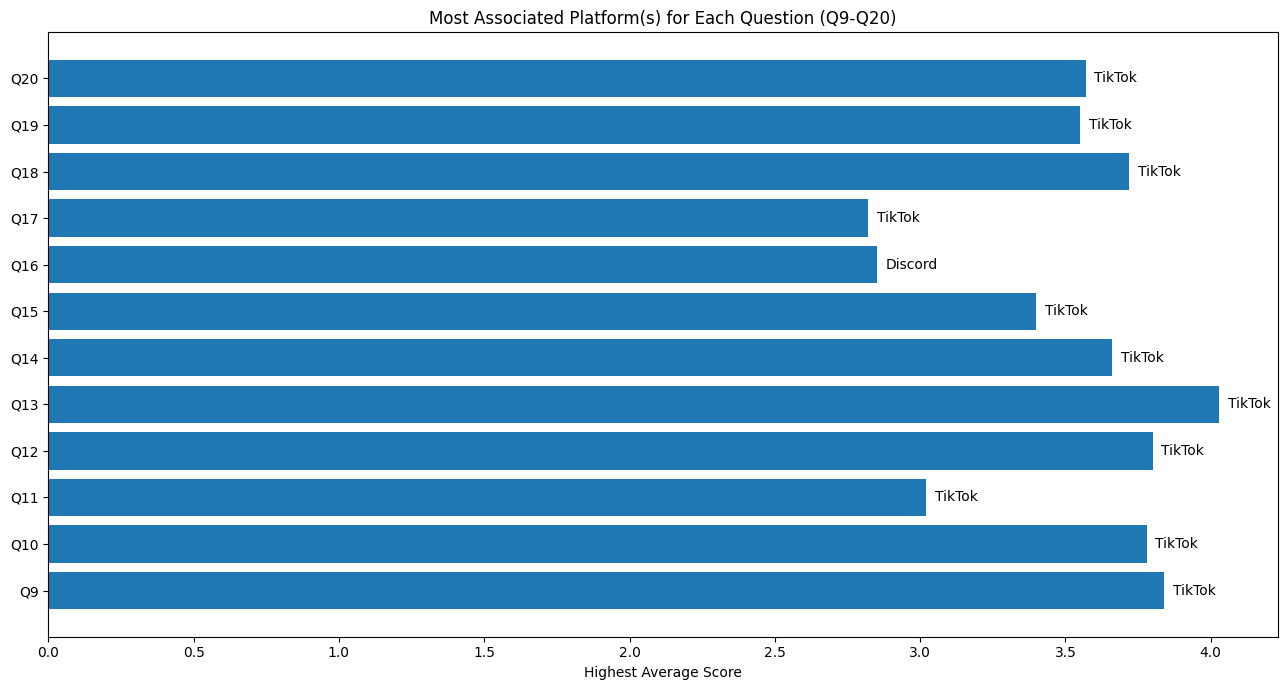

In [ ]:
# -----------------------------
# CALCULATE PLATFORM MEANS
# -----------------------------
results = []

for platform in platforms:

    subset = data[
        data[platform_col]
        .fillna("")
        .str.contains(platform, case=False)
    ]

    if len(subset) == 0:
        continue

    row = {"Platform": platform}

    for q_num, q_col in question_cols.items():

        row[f"Q{q_num}"] = pd.to_numeric(
            subset[q_col],
            errors="coerce"
        ).mean()

    results.append(row)

scores_data = pd.DataFrame(results)

# -----------------------------
# FIND MOST ASSOCIATED PLATFORM(S)
# includes ties
# -----------------------------
summary_rows = []

for q_num in range(9, 21):

    q_col = f"Q{q_num}"

    max_score = scores_data[q_col].max()

    best_platforms = scores_data.loc[
        scores_data[q_col] == max_score,
        "Platform"
    ].tolist()

    summary_rows.append({
        "Question": q_col,
        "Most Associated Platform(s)": ", ".join(best_platforms),
        "Average Score": round(max_score, 2)
    })

summary_data = pd.DataFrame(summary_rows)

print(summary_data)

# -----------------------------
# VISUALIZATION WITH TIES
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    summary_data["Question"],
    summary_data["Average Score"]
)

for i, bar in enumerate(bars):

    platforms = summary_data.iloc[i]["Most Associated Platform(s)"]

    ax.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        platforms,
        va="center"
    )

ax.set_xlabel("Highest Average Score")
ax.set_title("Most Associated Platform(s) for Each Question (Q9-Q20)")

plt.tight_layout()
plt.show()